### Histogram Equalization?
Histogram Equalization is an image processing technique that adjusts the contrast of an image by using its histogram. To enhance the image’s contrast, it spreads out the most frequent pixel intensity values or stretches out the intensity range of the image. By accomplishing this, histogram equalization allows the image’s areas with lower contrast to gain a higher contrast.

##### Steps to implement Histogram Equalization

Step 1:Calculate the Histogram
* The histogram shows the frequency of each intensity value(brightness) in the image

Step 2:Compute the cumulative Distribution Function
* The CDF sccumulates the frequencies of intensity levels.It helps us understand how the intensity values are distributed across the image.

Step 3:Map intensity values
* Using the CDF,the old intensity values are mapped to new ones so that the distribution spreads across the entire intensity range.

Step 4:Generate the Equalized Image
* Replace the old pixel intensities with the new mapped values

### 📸 Sample Grayscale Image (3×3)

|     |     |     |
|-----|-----|-----|
| 52  | 55  | 61  |
| 59  | 79  | 61  |
| 55  | 52  | 59  |

#### Step 1: Compute Histogram

List all pixel values:

[52, 55, 61, 59, 79, 61, 55, 52, 59]

Frequency (Histogram):

| Intensity | Frequency |
|-----------|-----------|
| 52        | 2         |
| 55        | 2         |
| 59        | 2         |
| 61        | 2         |
| 79        | 1         |

#### Step 2: Normalize the Histogram (Probability)


Total pixels = 9

| Intensity | Frequency | Probability |
|-----------|-----------|-------------|
| 52        | 2         | 2/9 ≈ 0.222 |
| 55        | 2         | 0.222       |
| 59        | 2         | 0.222       |
| 61        | 2         | 0.222       |
| 79        | 1         | 0.111       |

#### Step 3: Compute Cumulative Distribution Function (CDF)

| Intensity | CDF    | New Value |
|-----------|--------|-----------|
| 52        | 0.222  | 57        |
| 55        | 0.444  | 113       |
| 59        | 0.666  | 170       |
| 61        | 0.888  | 226       |
| 79        | 1.000  | 255       |


#### Step 4: Map Old Intensities to New Values

Formula :

**New Intensity** = $\text{round}(\text{CDF} \times (L - 1)) = \text{round}(\text{CDF} \times 255)$



| Intensity | CDF    | New Value |
|-----------|--------|-----------|
| 52        | 0.222  | 57        |
| 55        | 0.444  | 113       |
| 59        | 0.666  | 170       |
| 61        | 0.888  | 226       |
| 79        | 1.000  | 255       |

#### Step 5: Apply New Values to the Image

|     |     |     |
|-----|-----|-----|
| 57  | 113 | 226 |
| 170 | 255 | 226 |
| 113 | 57  | 170 |

#### Result
The new image has better contrast spread across the entire range (from 57 to 255 instead of 52 to 79), making it easier to see variations in brightness.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
image = cv2.imread("asserts/giraffe-Kenya.png")

if image is None:
    print("Error")
else:
    print("image loaded successfully!")

image loaded successfully!


In [7]:
image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
image_greyscale = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

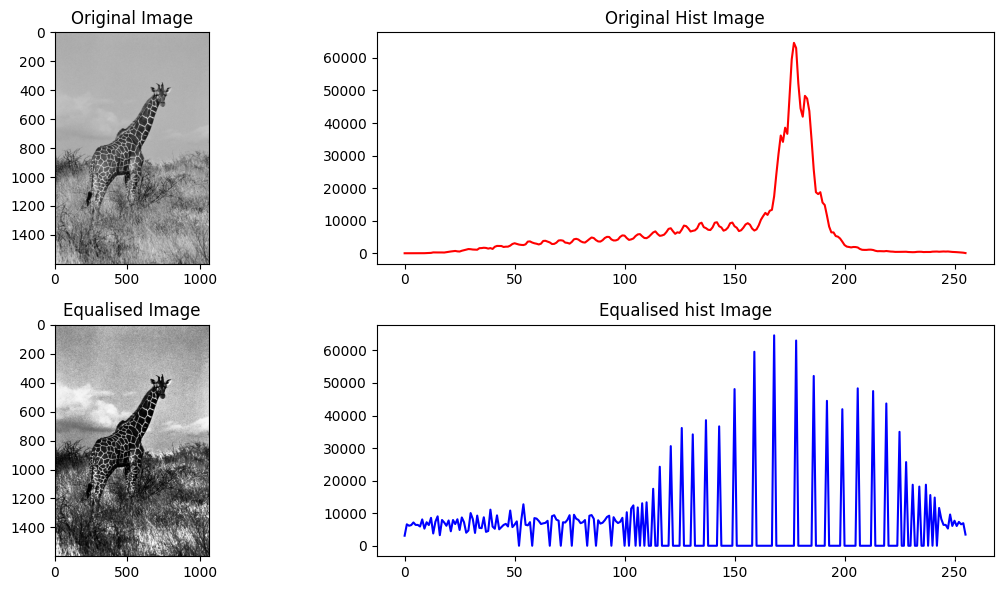

In [22]:
hist,bins = np.histogram(image_greyscale.flatten(),256,[0,256])

# perform histogram equalization

equalised_image = cv2.equalizeHist(image_greyscale)

# Compute histogram for equalized image

equalised_hist,bins = np.histogram(equalised_image.flatten(),256,[0,256])

plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(image_greyscale,cmap='gray')
plt.title('Original Image')

plt.subplot(2,2,2)
plt.plot(hist,color='red')
plt.title('Original Hist Image')

plt.subplot(2,2,3)
plt.imshow(equalised_image,cmap='gray')
plt.title('Equalised Image')

plt.subplot(2,2,4)
plt.plot(equalised_hist,color='blue')
plt.title('Equalised hist Image')

plt.tight_layout()
plt.show()

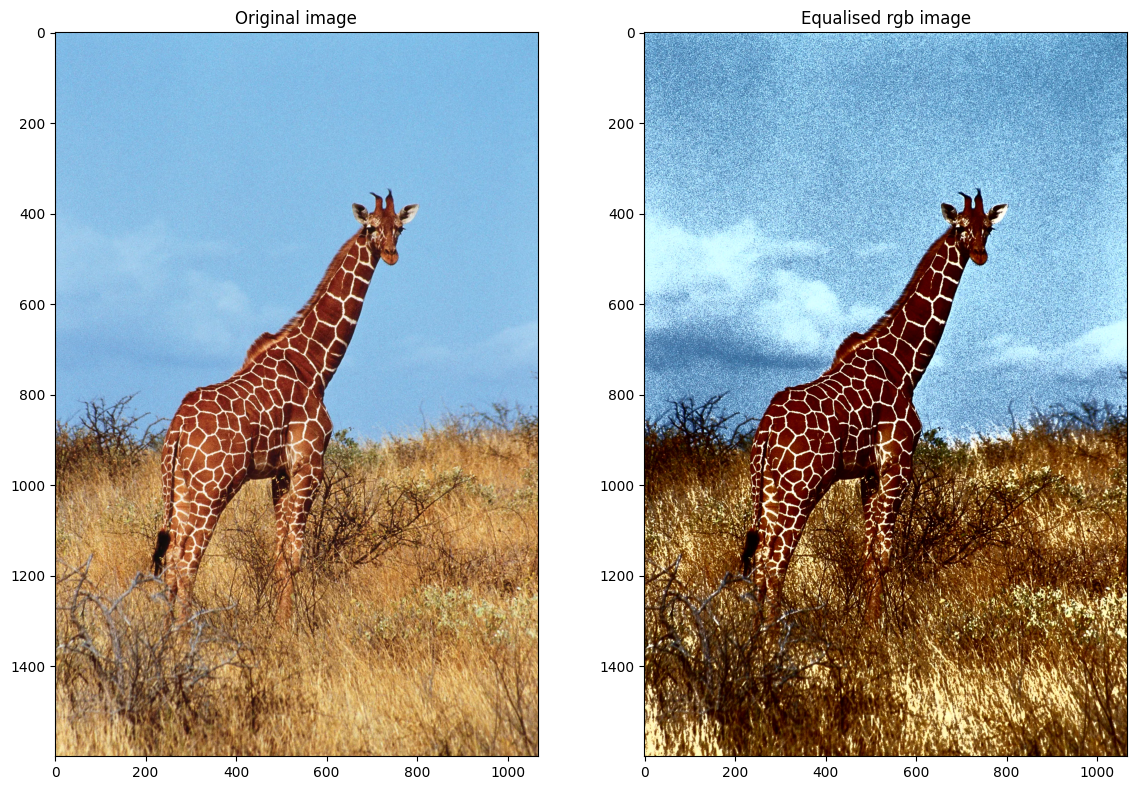

In [24]:
image_yuv = cv2.cvtColor(image,cv2.COLOR_BGR2YUV)
image_yuv[:,:,0] = cv2.equalizeHist(image_yuv[:,:,0])

equalised_color_image = cv2.cvtColor(image_yuv,cv2.COLOR_YUV2BGR)
equalised_color_image_RGB = cv2.cvtColor(equalised_color_image,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title('Original image')

plt.subplot(1,2,2)
plt.imshow(equalised_color_image_RGB)
plt.title('Equalised rgb image')

plt.tight_layout()
plt.show()
